<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B0%D1%83%D0%B4%D0%B8%D0%BE%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Загрузите датасет по ссылке

    **Toronto emotional speech set (TESS)**:

    https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi:10.5683/SP2/E8H2MF

    Ссылка для загрузки данных: https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip

2. Подготовьте и разделите данные, которые вы загрузили по ссылке: https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip  
на обучающие и тестовые
3. Из этих данных, разработайте классификатор, показывающий на тесте точность распознавания эмоции не менее 98%;
5. Загрузите второй датасет, который находится по этой ссылке:

    **Surrey Audio-Visual Expressed Emotion (SAVEE)**:

    https://www.kaggle.com/ejlok1/surrey-audiovisual-expressed-emotion-savee

    Ссылка для загрузки данных: https://storage.yandexcloud.net/aiueducation/Content/base/l12/archive.zip

6. Протестируйте обученный классификатор на файлах из датасета **SAVEE** по вашему выбору;
7. Сделайте выводы.

In [1]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM
from tensorflow.keras.layers import MaxPooling1D, AveragePooling1D, SpatialDropout1D

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

import IPython.display as ipd             # Проигрывание аудио в colab

%matplotlib inline

In [2]:
# Загрузка датасета
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip', None, quiet=True)

'dataverse_files.zip'

In [3]:
# Распаковка архива на локальный диск
!unzip -qo dataverse_files.zip
!mkdir dataverse_files
!mv *.wav ./dataverse_files

In [4]:
!ls dataverse_files
!ls dataverse_files | wc -l

OAF_back_angry.wav	OAF_reach_happy.wav	 YAF_jail_sad.wav
OAF_back_disgust.wav	OAF_reach_neutral.wav	 YAF_jar_angry.wav
OAF_back_fear.wav	OAF_reach_ps.wav	 YAF_jar_disgust.wav
OAF_back_happy.wav	OAF_reach_sad.wav	 YAF_jar_fear.wav
OAF_back_neutral.wav	OAF_read_angry.wav	 YAF_jar_happy.wav
OAF_back_ps.wav		OAF_read_disgust.wav	 YAF_jar_neutral.wav
OAF_back_sad.wav	OAF_read_fear.wav	 YAF_jar_ps.wav
OAF_bar_angry.wav	OAF_read_happy.wav	 YAF_jar_sad.wav
OAF_bar_disgust.wav	OAF_read_neutral.wav	 YAF_join_angry.wav
OAF_bar_fear.wav	OAF_read_ps.wav		 YAF_join_disgust.wav
OAF_bar_happy.wav	OAF_read_sad.wav	 YAF_join_fear.wav
OAF_bar_neutral.wav	OAF_red_angry.wav	 YAF_join_happy.wav
OAF_bar_ps.wav		OAF_red_disgust.wav	 YAF_join_neutral.wav
OAF_bar_sad.wav		OAF_red_fear.wav	 YAF_join_ps.wav
OAF_base_angry.wav	OAF_red_happy.wav	 YAF_join_sad.wav
OAF_base_disgust.wav	OAF_red_neutral.wav	 YAF_judge_angry.wav
OAF_base_fear.wav	OAF_red_ps.wav		 YAF_judge_disgust.wav
OAF_base_happy.wav	OAF_red_sad.wav	

These stimuli were modeled on the Northwestern University Auditory Test No. 6 (NU-6; Tillman & Carhart, 1966). A set of 200 target words were spoken in the carrier phrase "Say the word _____' by two actresses (aged 26 and 64 years) and recordings were made of the set portraying each of seven emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). There are 2800 stimuli in total. Two actresses were recruited from the Toronto area. Both actresses speak English as their first language, are university educated, and have musical training. Audiometric testing indicated that both actresses have thresholds within the normal range. (2010-06-21)

In [5]:
# Функция загрузки аудио и вывода текстовой информации
# о сигнале, а также проигрывателя аудио

def load_audio(audio_path,       # путь к файлу с аудио
               show_text=True,   # показывать ли текстовую сводку по аудио
               show_player=True  # выводить ли проигрыватель в ячейку
               ):
    # Загрузка аудиофайла, на выходе:
    # x  - массив данных временного ряда аудио
    # sr - частота дискретизации временного ряда
    x, sr = librosa.load(audio_path)

    if show_text:
        # Вывод текстовых данных о сигнале
        print(f'Типы данных x и sr: {type(x)}, {type(sr)}')
        print(f'Форма данных x: {x.shape}, sr = {sr}')
        print('Продолжительность сигнала:', round(x.shape[0]/sr), 'с.\n')

    if show_player:
        # Вывод проигрывателя в ячейку colab
        ipd.display(ipd.Audio(audio_path))

    # Возврат загруженных данных для дальнейшего использования
    return x, sr

In [6]:
# Загрузка файла примера
x, sr = load_audio('dataverse_files/OAF_back_angry.wav')


Типы данных x и sr: <class 'numpy.ndarray'>, <class 'int'>
Форма данных x: (33936,), sr = 22050
Продолжительность сигнала: 2 с.



In [7]:
# Загрузка файла примера
x, sr = load_audio('dataverse_files/YAF_kill_sad.wav')

Типы данных x и sr: <class 'numpy.ndarray'>, <class 'int'>
Форма данных x: (47741,), sr = 22050
Продолжительность сигнала: 2 с.



In [8]:
FILE_DIR = './dataverse_files'            # Папка с файлами датасета
CLASS_LIST = list(set(list(map(lambda name: name.replace('.wav', '').split('_')[2], os.listdir(FILE_DIR)))))
CLASS_LIST.sort()                         # Сортировка списка классов для фиксации порядка меток
CLASS_COUNT = len(CLASS_LIST)             # Количество классов
FILE_INDEX_TRAIN_SPLIT = 90               # Количество файлов каждого класса на основной набор
VALIDATION_SPLIT = 0.1                    # Доля проверочной выборки в основном наборе
N_FFT = 8192                              # Размер окна преобразования Фурье для расчета спектра
HOP_LENGTH = 512                          # Объем данных для расчета одного набора признаков
display(CLASS_LIST)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

In [9]:
def get_class_index_from_name(name, class_list):
    #print(name)
    class_name = name.replace('.wav', '').split('_')[2]
    #print(class_name)
    return class_list.index(class_name)

In [10]:
# Функция параметризации аудио

def get_features(y,                     # волновое представление сигнала
                 sr,                    # частота дискретизации сигнала y
                 n_fft=N_FFT,           # размер скользящего окна БПФ
                 hop_length=HOP_LENGTH  # шаг скользящего окна БПФ
                 ):
    # Вычисление различных параметров (признаков) аудио

    # Хромаграмма
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Мел-кепстральные коэффициенты
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Среднеквадратическая амплитуда
    rmse = librosa.feature.rms(y=y, hop_length=hop_length)
    # Спектральный центроид
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Ширина полосы частот
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Спектральный спад частоты
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Пересечения нуля
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)

    # Сборка параметров в общий список:
    # На один файл один усредненный вектор признаков
    features = {'rmse': rmse.mean(axis=1, keepdims=True),
                'spct': spec_cent.mean(axis=1, keepdims=True),
                'spbw': spec_bw.mean(axis=1, keepdims=True),
                'roff': rolloff.mean(axis=1, keepdims=True),
                'zcr' : zcr.mean(axis=1, keepdims=True),
                'mfcc': mfcc.mean(axis=1, keepdims=True),
                'stft': chroma_stft.mean(axis=1, keepdims=True)}

    return features

In [11]:
# Функция объединения признаков в набор векторов

def stack_features(feat  # словарь признаков, отдельные векторы по ключу каждого признака
                   ):
    features = None
    for v in feat.values():
        features = np.vstack((features, v)) if features is not None else v

    return features.T

In [12]:
# Функция формирования набора признаков и метки класса для аудиофайла

def get_feature_list_from_file(song_name):    # имя аудиофайла
    # Загрузка в y первых duration_sec секунд аудиосигнала
    y, sr = librosa.load(song_name, mono=True)

    # Извлечение параметров из аудиосигнала
    features = get_features(y, sr)
    feature_set = stack_features(features)
    class_index = get_class_index_from_name(os.path.basename(song_name), CLASS_LIST)
    # Перевод номера класса в one hot encoding
    y_label = to_categorical(class_index, CLASS_COUNT)

    return feature_set, y_label

In [13]:
#проверка набора данных к одному файлу
file_index=0
files = os.listdir(FILE_DIR)
file = files[file_index]
song_name = f'{FILE_DIR}/{file}'
feature_set, y_label = get_feature_list_from_file(song_name)
display(feature_set.shape)
display(y_label)
display(feature_set)

(1, 37)

array([0., 0., 1., 0., 0., 0., 0.])

array([[ 7.85623640e-02,  2.85175292e+03,  2.34126022e+03,
         4.80741577e+03,  1.89305866e-01, -7.55371246e+01,
         7.17305527e+01, -4.70362806e+00,  8.15186405e+00,
        -6.07742167e+00, -8.70455360e+00,  1.12589350e+01,
        -2.51646557e+01, -3.87545490e+00, -9.27776754e-01,
        -1.93989601e+01,  9.59391594e+00, -1.11566238e+01,
         8.52427185e-01, -5.63825941e+00, -1.03261175e+01,
        -8.02660751e+00, -4.07119179e+00, -3.79461861e+00,
         2.10363102e+01,  3.52617681e-01,  4.27643538e-01,
         3.07539344e-01,  3.88580650e-01,  5.02381206e-01,
         5.43562591e-01,  4.12161201e-01,  1.07820071e-01,
         8.45535696e-02,  1.11748740e-01,  1.88227981e-01,
         3.07830572e-01]])

In [14]:
# Функция формирования подвыборки признаков и меток класса для одного файла

def process_file(
                 file_index,   # индекс (порядковый номер) аудиофайла в папке класса
                 files_list # список файлов
                 ):
    x_list = []
    y_list = []
    file_name = files_list[file_index]

    # Извлечение имени произведения
    song_name = f'{FILE_DIR}/{file_name}'

    # Выборка признаков и метки класса для произведения
    feature_set, y_label = get_feature_list_from_file(song_name)

    # Добавление данных в наборы
    for j in range(feature_set.shape[0]):
        x_list.append(feature_set[j])
        y_list.append(y_label)

    # Возврат имени файла и numpy-массивов призанков и меток класса
    return song_name, \
           np.array(x_list).astype('float32'), \
           np.array(y_list).astype('float32')

In [15]:
name, file_x_data, file_y_data = process_file(1, os.listdir(FILE_DIR))
display(file_x_data, file_y_data)
print(file_x_data.shape, file_y_data.shape, name)
display(CLASS_LIST)

array([[ 6.9384404e-02,  3.0618667e+03,  2.1812554e+03,  5.2066821e+03,
         2.1035880e-01, -7.6601494e+01,  4.4384357e+01, -2.8442244e+01,
         1.5247096e+01, -3.5161350e+01, -1.8847567e+01, -8.1994810e+00,
        -2.8776466e+01, -2.0508118e+00, -8.2875080e+00, -1.3621959e+01,
         4.4871922e+00, -1.6273203e+01,  7.2155142e+00, -8.9380407e+00,
        -7.5979443e+00, -4.0356798e+00, -1.1471279e+00, -6.9172649e+00,
         3.6066148e+00,  4.5098522e-01,  4.5411000e-01,  3.3805296e-01,
         2.5841060e-01,  2.1614739e-01,  1.6056766e-01,  2.1275641e-01,
         3.8467064e-01,  4.0840220e-01,  2.1302362e-01,  2.7026126e-01,
         5.0253373e-01]], dtype=float32)

array([[1., 0., 0., 0., 0., 0., 0.]], dtype=float32)

(1, 37) (1, 7) ./dataverse_files/YAF_fail_angry.wav


['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']

In [16]:
# Функция формирования набора данных из файлов всех классов по диапазону номеров файлов

def extract_data(file_index_start,          # начальный индекс аудиофайла
                 file_index_end,            # конечный индекс аудиофайла (не достигая)
                 ):

    # Списки для последовательностей входных данных и меток класса
    x_data = None
    y_data = None

    # Фиксация времени старта формирования выборки
    curr_time = time.time()

    # Для всех классов:
    files_list = os.listdir(FILE_DIR)
    files_indexes = range(len(files_list))[file_index_start:file_index_end]
    for file_index in files_indexes:
        # Обработка одного файла и добавление данных к общим массивам
        _, file_x_data, file_y_data = process_file(file_index, files_list)
        x_data = file_x_data if x_data is None else np.vstack([x_data, file_x_data])
        y_data = file_y_data if y_data is None else np.vstack([y_data, file_y_data])

    # Вывод информации о готовности обработки датасета
    print(f'Обработка завершена -> {round(time.time() - curr_time)} c')
    # Возврат массивов набора данных
    return x_data, y_data

In [17]:
# Формирование тренировочного (основного) набора данных
file_index_end = int(len(os.listdir(FILE_DIR))*FILE_INDEX_TRAIN_SPLIT/100)
print(f'file_index_end={file_index_end}')
x_train_data, y_train_data = extract_data(0, file_index_end)
print(x_train_data.shape, x_train_data.dtype)

file_index_end=2520
Обработка завершена -> 283 c
(2520, 37) float32


In [18]:
# Сохранение/восстановление датасета аудио
with open('tess_audio_data_mean.pickle', 'wb') as f:
    pickle.dump((x_train_data, y_train_data), f)

with open('tess_audio_data_mean.pickle', 'rb') as f:
    x_train_data, y_train_data = pickle.load(f)

In [19]:
# Вывод формы данных обучающего набора
print(x_train_data.shape, x_train_data.dtype)
print(y_train_data.shape, y_train_data.dtype)

(2520, 37) float32
(2520, 7) float32


In [20]:
# Нормирование признаков в соответствии со стандартным нормальным распределением
x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data)

In [21]:
# Разделение набора данных на обучающую и проверочную выборки
# Параметр stratify указывает метки классов, по которым происходит балансировка разделения
x_train, x_val, y_train, y_val = train_test_split(x_train_data_scaled,
                                                  y_train_data,
                                                  stratify=y_train_data,
                                                  test_size=VALIDATION_SPLIT)

In [22]:
# Проверка формы и типа данных обучающей и проверочной выборок
print(x_train.shape, x_train.dtype)
print(y_train.shape, y_train.dtype)
print()
print(x_val.shape, x_val.dtype)
print(y_val.shape, y_val.dtype)

(2268, 37) float32
(2268, 7) float32

(252, 37) float32
(252, 7) float32


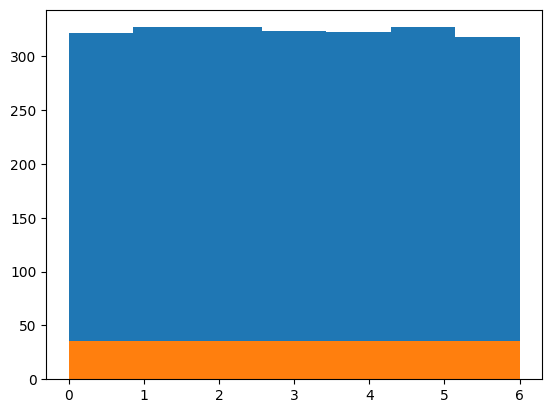

In [23]:
# Проверка сбалансированности выборок по классам
plt.hist(np.argmax(y_train, axis=1), CLASS_COUNT)
plt.hist(np.argmax(y_val, axis=1), CLASS_COUNT)
plt.show()

In [24]:
# Функция сборки и обучения классификатора на полносвязных слоях

def create_train_classifier(in_shape,      # форма входных данных модели
                            epochs=200,    # количество эпох обучения
                            batch_size=20  # размер батча
                            ):
    model = Sequential()
    model.add(Dense(256, activation='relu', input_shape=in_shape))
    model.add(Dropout(0.3))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(BatchNormalization())
    model.add(Dense(CLASS_COUNT, activation='softmax'))

    # Компиляция модели
    model.compile(optimizer=Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    model.summary()

    # Обучение модели
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графика точности распознавания на обучающей и проверочной выборках
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['accuracy'], label='Точность на обучающем наборе')
    plt.plot(history.history['val_accuracy'], label='Точность на проверочном наборе')
    plt.xticks(range(0, epochs, 10))
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()
    plt.show()

    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,127 (207.53 KB)

 Trainable params: 52,231 (204.03 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.1797 - loss: 2.3673 - val_accuracy: 0.3849 - val_loss: 1.6223
Epoch 2/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3609 - loss: 1.7069 - val_accuracy: 0.6468 - val_loss: 1.1211
Epoch 3/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4384 - loss: 1.4708 - val_accuracy: 0.8452 - val_loss: 0.7486
Epoch 4/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5636 - loss: 1.2078 - val_accuracy: 0.8889 - val_loss: 0.5510
Epoch 5/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6577 - loss: 1.0218 - val_accuracy: 0.9087 - val_loss: 0.4279
Epoch 6/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6642 - loss: 0.9243 - val_accuracy: 0.9206 - val_loss: 0.3547
Epoch 7/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7067 - loss: 0.8060 - val_accuracy: 0.9286 - val_loss: 0.3021
Epoch 8/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7551 - loss: 0.7361 - val_ac

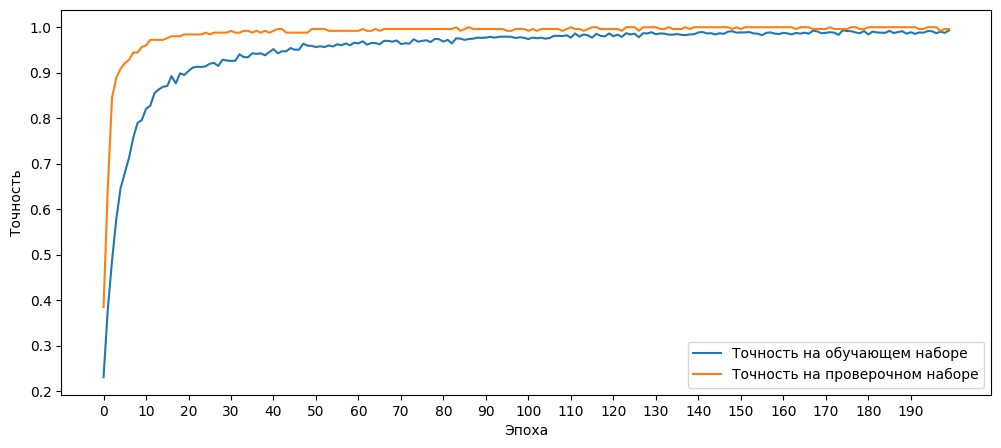

In [25]:
model = create_train_classifier(x_train.shape[1:])

In [26]:
model.save('tess_model_audio_mean.keras')
with open('tess_audio_train_val_mean.pickle', 'wb') as f:
    pickle.dump((x_train, y_train, x_val, y_val, x_scaler), f)

model = load_model('tess_model_audio_mean.keras')
with open('tess_audio_train_val_mean.pickle', 'rb') as f:
    x_train, y_train, x_val, y_val, x_scaler = pickle.load(f)

In [27]:
file_index_start = int(len(os.listdir(FILE_DIR))*FILE_INDEX_TRAIN_SPLIT/100)
file_index_end = len(os.listdir(FILE_DIR))
x_test, y_test = extract_data(file_index_start, file_index_end)
print(x_test.shape, x_test.dtype)
x_test = x_scaler.transform(x_test)

Обработка завершена -> 33 c
(280, 37) float32


In [28]:
# Функция оценки точности модели на заданной выборке

def eval_model(model,  # обученная модель нейронной сети
               x,      # входные данные
               y_true  # выходные данные (верные ответы)
               ):
    loss, acc = model.evaluate(x, y_true)
    print(f'Ошибка: {loss}, точность: {acc}')

    # Построение матрицы ошибок
    y_pred = model.predict(x)
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title('Матрица ошибок нормализованная')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9953 - loss: 0.0083
Ошибка: 0.008270621299743652, точность: 0.9960317611694336
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


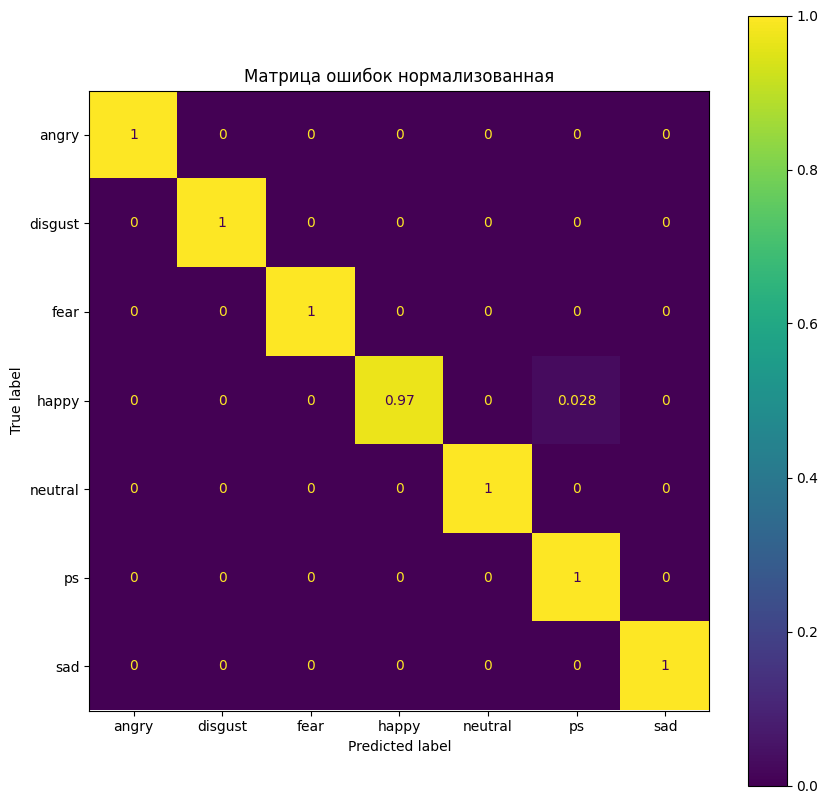

In [29]:
# Оценка точности сети на проверочной выборке
eval_model(model, x_val, y_val)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9965 - loss: 0.0190
Ошибка: 0.020592302083969116, точность: 0.9964285492897034
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


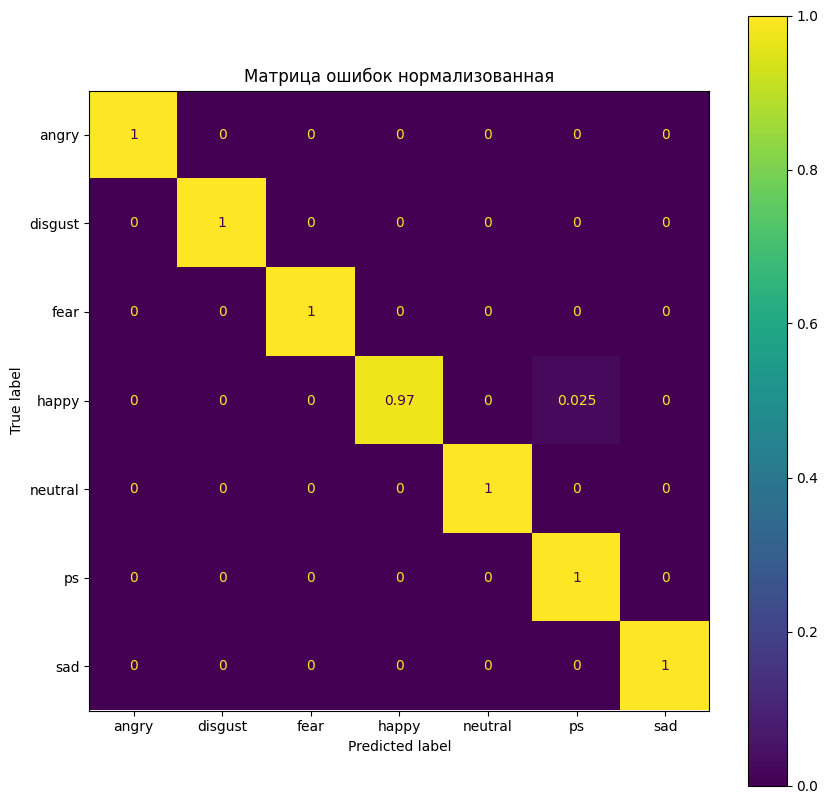

In [30]:
# Оценка точности сети на тестовой выборке
eval_model(model, x_test, y_test)

In [31]:
# Классификация файла и визуализация предсказания модели для него

def classify_file(model,        # обученная модель классификатора
                  x_scaler,     # настроенный нормировщих входных данных
                  file_index,    # индекс (порядковый номер) аудиофайла в папке
                  files_list  # список файлов
                  ):
    # Подготовка выборки данных файла произведения
    file_name = files_list[file_index]
    class_index = get_class_index_from_name(file_name, CLASS_LIST)
    song_name, file_x_data, file_y_data = process_file(file_index, files_list)
    # Нормирование признаков уже настроенным нормировщиком
    file_x_data = x_scaler.transform(file_x_data)

    print('Файл:', song_name)
    print('Векторы для предсказания:', file_x_data.shape)

    # Вычисление предсказания по выборке
    predict = model.predict(file_x_data)
    # Определение среднего предсказания (голосование)
    predict_mean = predict.mean(axis=0)
    # Определение индекса класса по результату голосования
    predict_class_index = np.argmax(predict_mean)
    # Вычисление признака правильного предсказания
    predict_good = predict_class_index == class_index

    # Визуализация предсказания сети для файла
    plt.figure(figsize=(10,3))
    print('Классификация сети:', CLASS_LIST[predict_class_index], '-', 'ВЕРНО :-)' if predict_good else 'НЕВЕРНО.')
    plt.title('Среднее распределение векторов предсказаний')
    plt.bar(CLASS_LIST, predict_mean, color='g' if predict_good else 'r')
    plt.show()
    print('---------------------------------------------------------------')

    # Возврат результата предсказания
    return predict_class_index

In [32]:
# Классификация и визуализация нескольких файлов каждого класса

def classify_test_files(model,       # обученная модель классификатора
                        x_scaler,    # настроенный нормировщих входных данных
                        from_index,  # индекс аудиофайла, с которого начинать визуализацию
                        n_files):    # количество файлов для визуализации
    predict_all = 0
    predict_good = 0
    y_true = []
    y_pred = []
    files_list = os.listdir(FILE_DIR)
    for file_index in range(from_index, from_index + n_files):
        file_name = files_list[file_index]
        class_index = get_class_index_from_name(file_name, CLASS_LIST)
        predict_class_index = classify_file(model, x_scaler, file_index, files_list)
        y_true.append(class_index)
        y_pred.append(predict_class_index)
        predict_all += 1
        predict_good += (predict_class_index == class_index)

    # Расчет и вывод итогов классификации
    good_ratio = round(predict_good / predict_all * 100., 2)
    print(f'=== Обработано образцов: {predict_all}, из них распознано верно: {predict_good}, доля верных: {good_ratio}% ===')

    # Построение матрицы ошибок без нормализации, покажет попадания в штуках
    cm = confusion_matrix(y_true, y_pred)
    display(cm)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(7,7))
    ax.set_title('Матрица ошибок по файлам аудио (не нормализованная)')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.show()

Файл: ./dataverse_files/YAF_lease_sad.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
Классификация сети: sad - ВЕРНО :-)


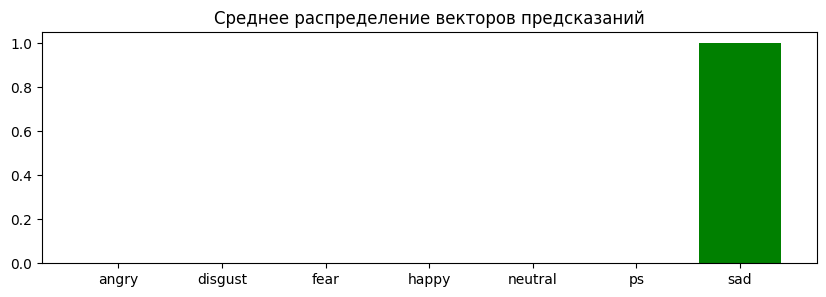

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_germ_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Классификация сети: angry - ВЕРНО :-)


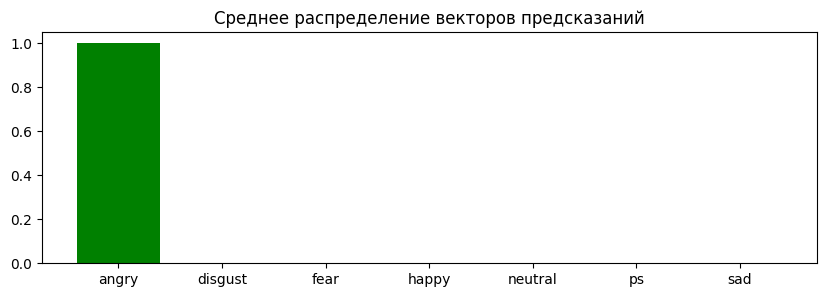

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_lore_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Классификация сети: angry - ВЕРНО :-)


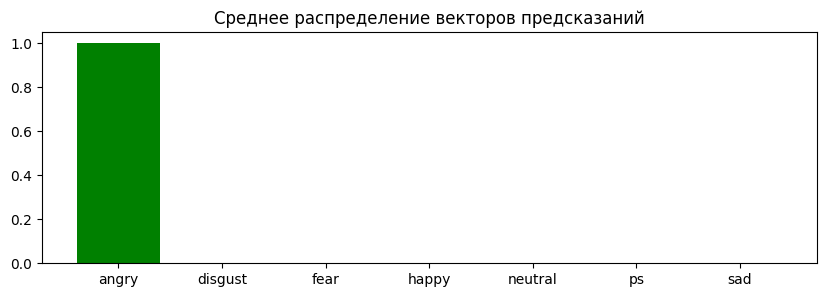

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_burn_disgust.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Классификация сети: disgust - ВЕРНО :-)


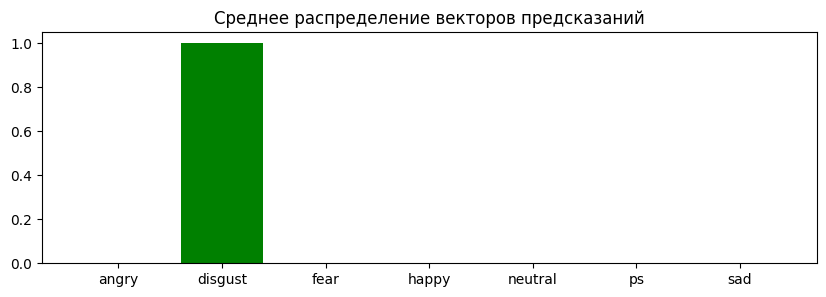

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_five_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Классификация сети: angry - ВЕРНО :-)


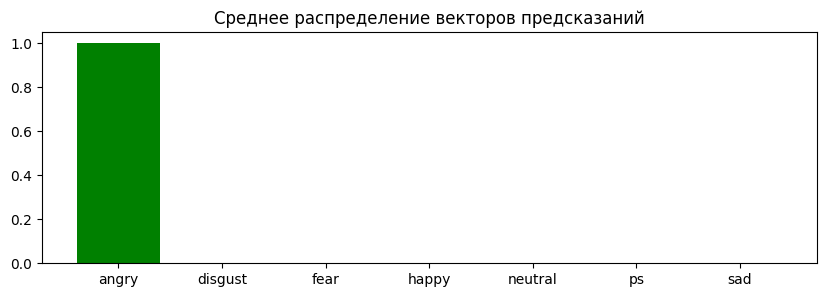

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_ditch_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Классификация сети: angry - ВЕРНО :-)


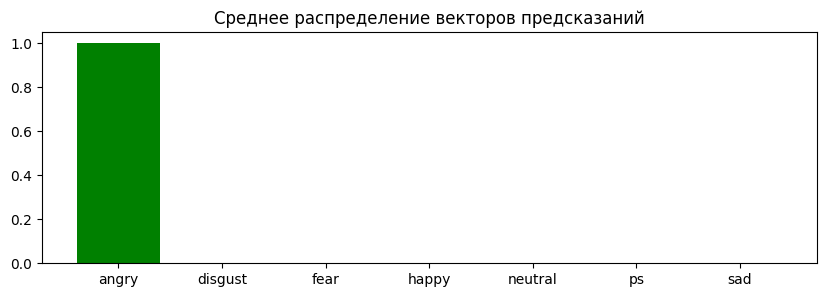

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_rush_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Классификация сети: angry - ВЕРНО :-)


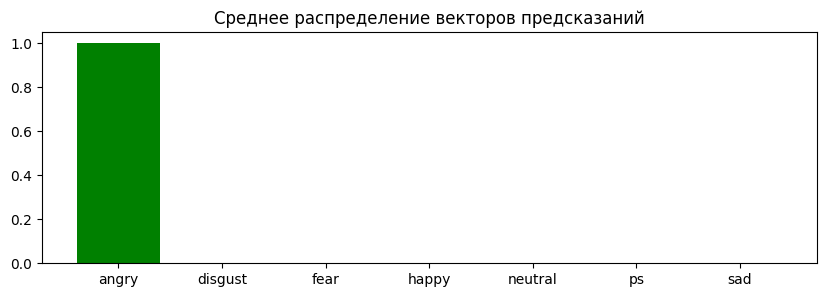

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_tire_disgust.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: disgust - ВЕРНО :-)


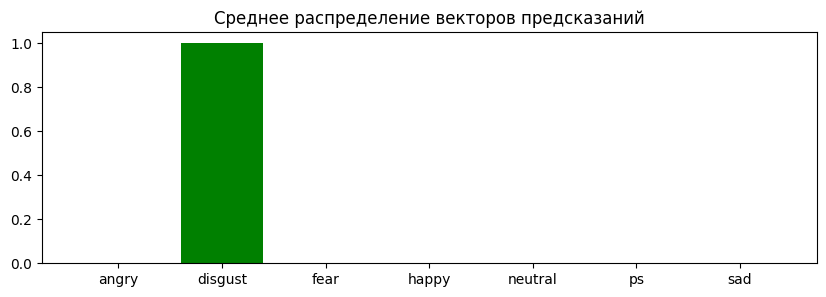

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_bar_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Классификация сети: angry - ВЕРНО :-)


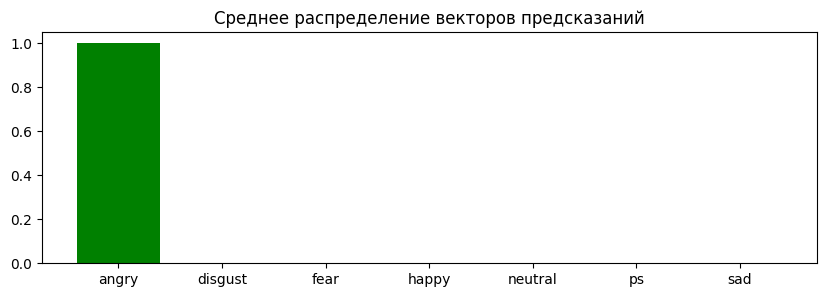

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_neat_sad.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Классификация сети: sad - ВЕРНО :-)


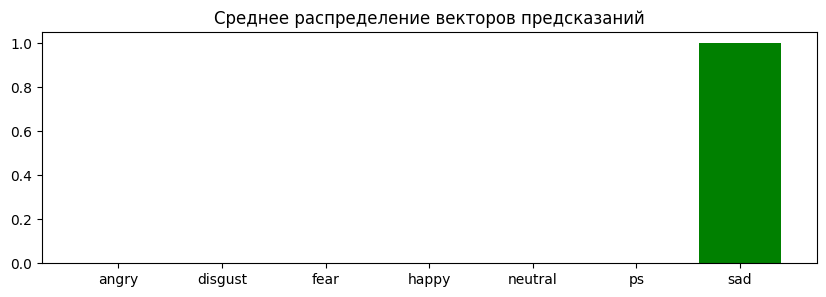

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_keen_happy.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Классификация сети: happy - ВЕРНО :-)


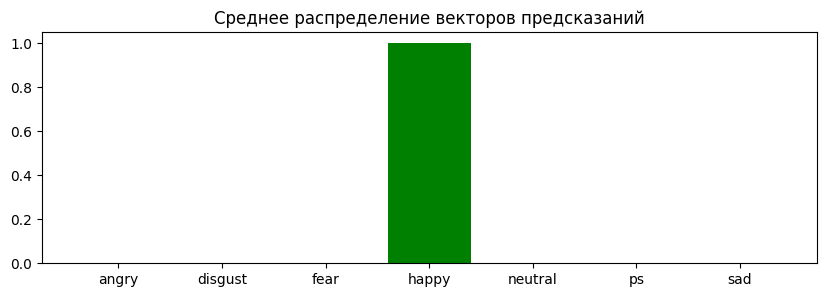

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_search_fear.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Классификация сети: fear - ВЕРНО :-)


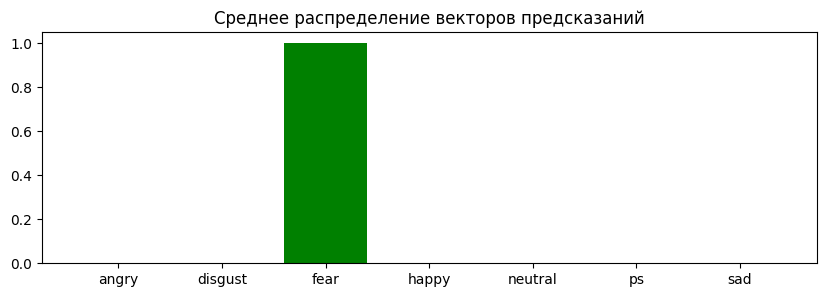

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_half_happy.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Классификация сети: happy - ВЕРНО :-)


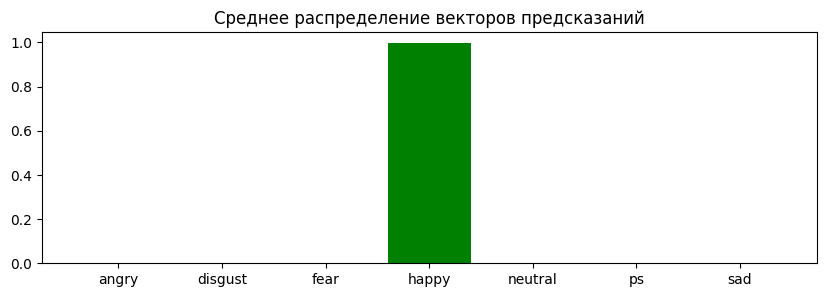

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_seize_happy.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Классификация сети: happy - ВЕРНО :-)


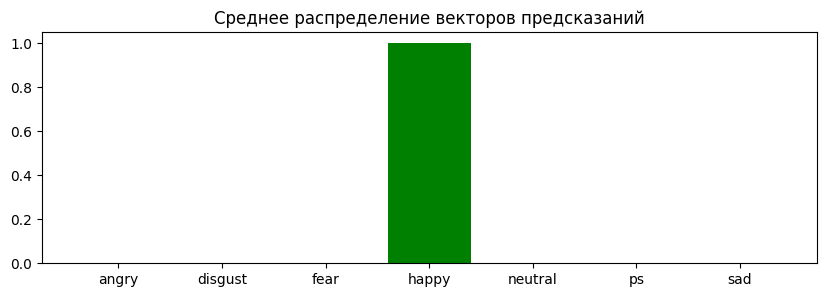

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_size_happy.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Классификация сети: happy - ВЕРНО :-)


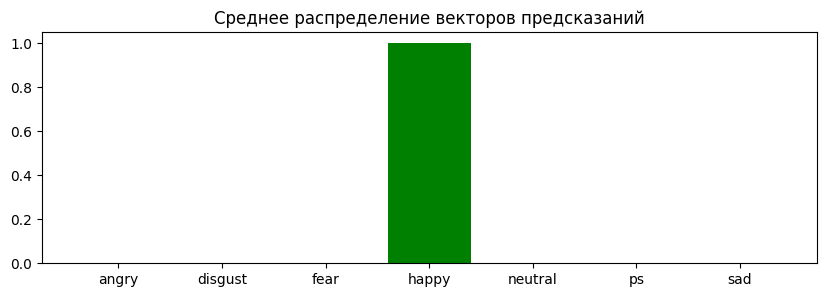

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_sell_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: angry - ВЕРНО :-)


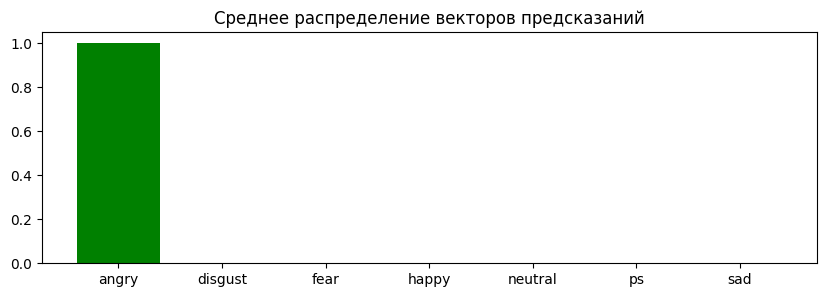

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_whip_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Классификация сети: angry - ВЕРНО :-)


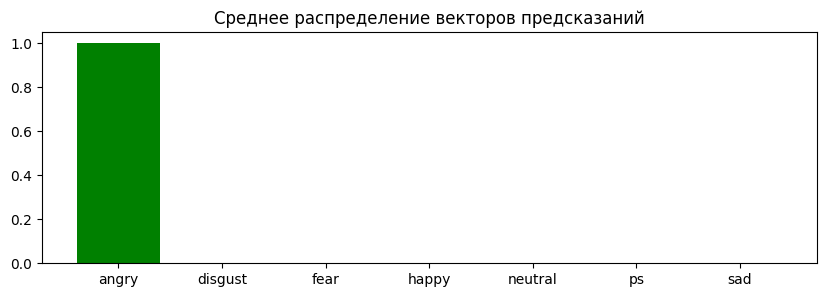

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_loaf_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Классификация сети: angry - ВЕРНО :-)


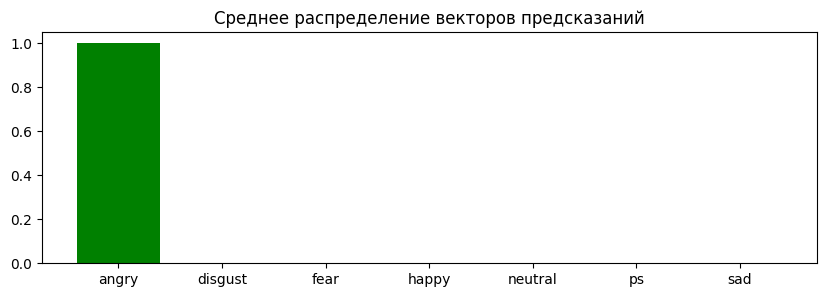

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_hire_sad.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: sad - ВЕРНО :-)


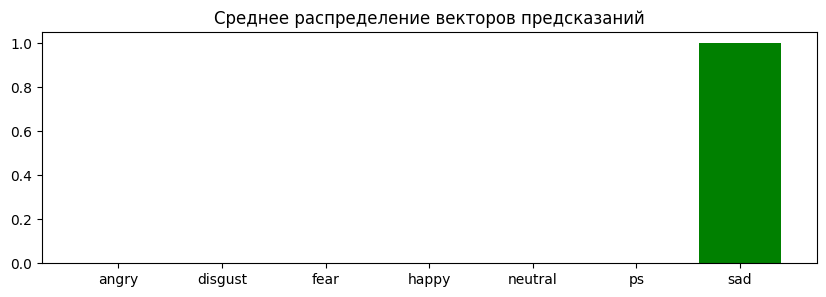

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_chief_fear.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Классификация сети: fear - ВЕРНО :-)


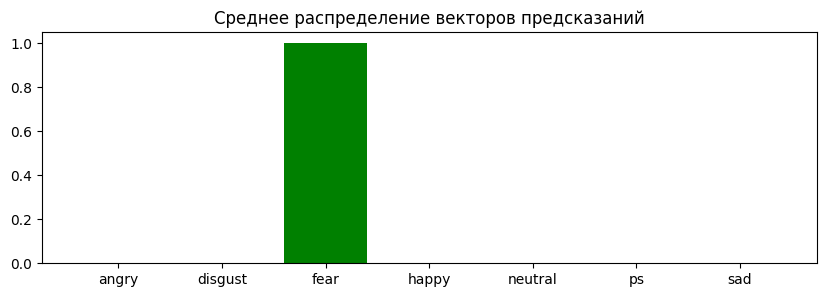

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_cause_sad.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: sad - ВЕРНО :-)


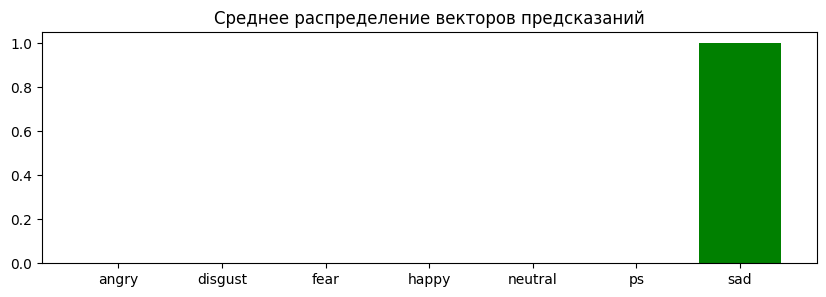

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_mill_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: angry - ВЕРНО :-)


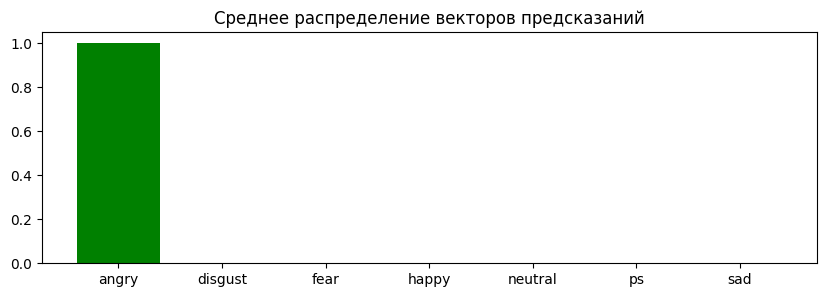

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_life_angry.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: angry - ВЕРНО :-)


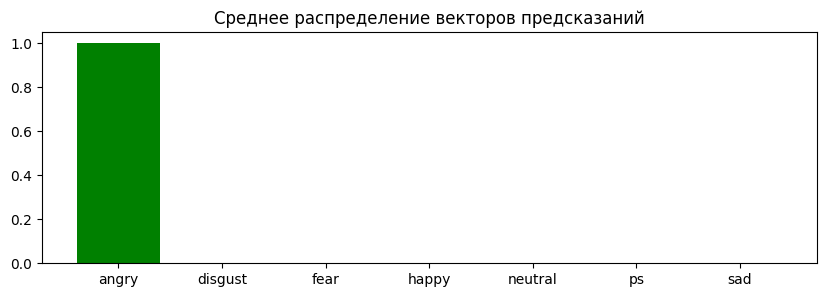

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_room_ps.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Классификация сети: ps - ВЕРНО :-)


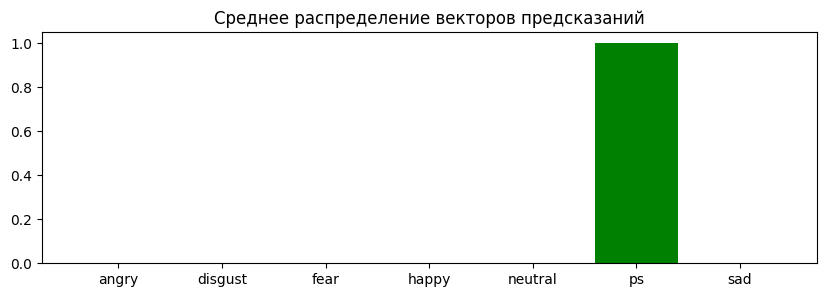

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_moon_ps.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: ps - ВЕРНО :-)


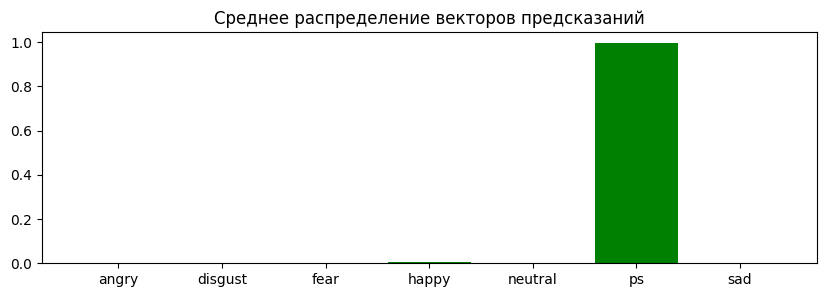

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_turn_sad.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Классификация сети: sad - ВЕРНО :-)


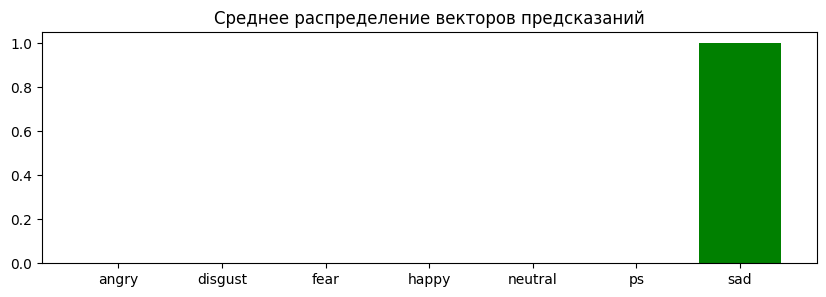

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_wash_ps.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Классификация сети: ps - ВЕРНО :-)


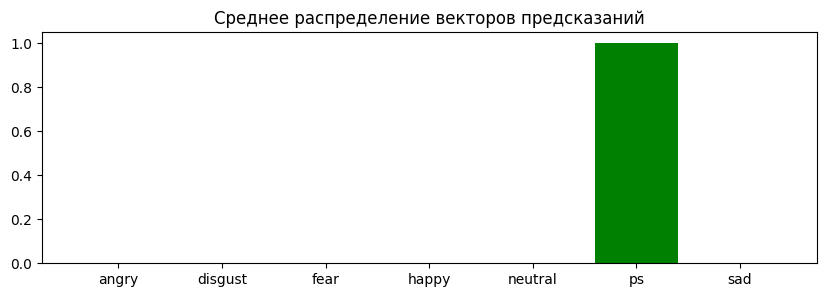

---------------------------------------------------------------
Файл: ./dataverse_files/OAF_vine_neutral.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Классификация сети: neutral - ВЕРНО :-)


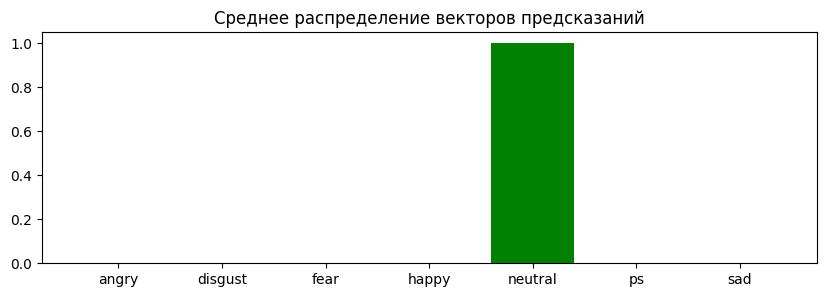

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_deep_neutral.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: neutral - ВЕРНО :-)


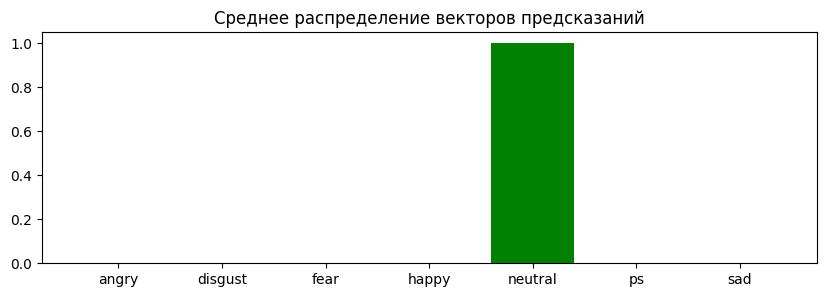

---------------------------------------------------------------
Файл: ./dataverse_files/YAF_sail_neutral.wav
Векторы для предсказания: (1, 37)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Классификация сети: neutral - ВЕРНО :-)


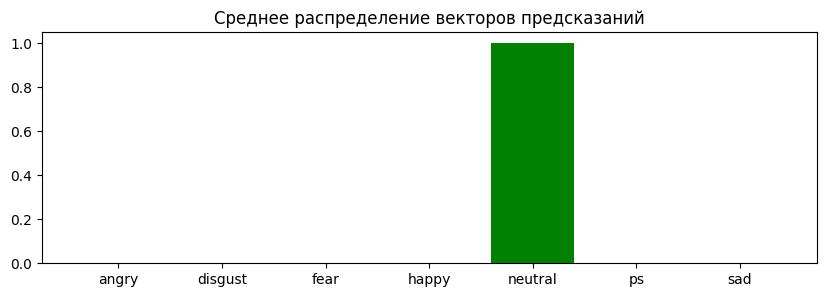

---------------------------------------------------------------
=== Обработано образцов: 30, из них распознано верно: 30, доля верных: 100.0% ===


array([[11,  0,  0,  0,  0,  0,  0],
       [ 0,  2,  0,  0,  0,  0,  0],
       [ 0,  0,  2,  0,  0,  0,  0],
       [ 0,  0,  0,  4,  0,  0,  0],
       [ 0,  0,  0,  0,  3,  0,  0],
       [ 0,  0,  0,  0,  0,  3,  0],
       [ 0,  0,  0,  0,  0,  0,  5]])

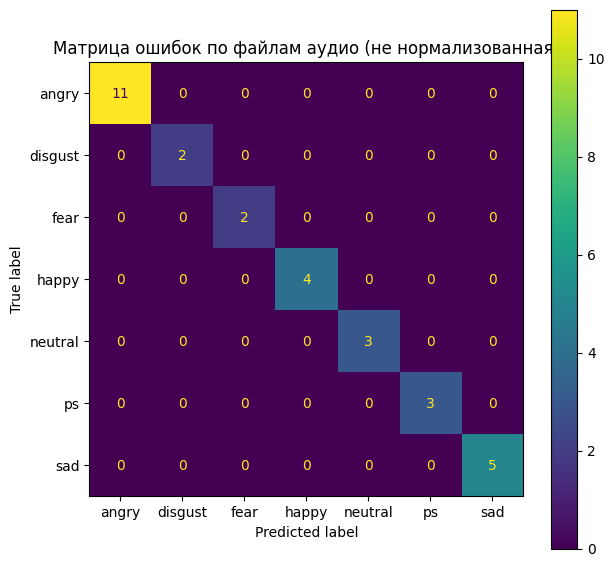

In [33]:
# Визуализация классификации файлов из тренировочного набора
classify_test_files(model, x_scaler, 50, 30)